# Thrivelines from a saved correlation matrix

Thrivelines show how a z-score is expected to evolve over one covariate step
(by default, one year). To estimate them we need to know the correlation matrix (= how strongly z-scores correlate across ages).

In pcntoolkit the correlation matrix lives in the `CorrelationMatrix` class, and everything downstream, scoring subjects and drawing
thrivelines, needs only that matrix plus a fitted normative model.

In this notebook we plot thrivelines using a precomputed correlation matrix. The matrix already carries everything learned from a longitudinal cohort, so no longitudinal data is needed to plot them.

> **Note:** the normative model is downloaded automatically from SURFdrive, but the correlation matrix exists in a private directory.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from pcntoolkit import CorrelationMatrix, NormativeModel, ZGainScore
from pcntoolkit.util.plotter import plot_thrivelines

## 1. Load precomputed correlation matrix

`load()` loads only one specific file layout: the velocity models from Johanna
Bayer's pipeline, saved in `batch_<n>_<region>/Velocity/<file>.pkl`. The region name is not stored inside the file, so it is read from the directory name.

In [8]:
MATRIX_PATH = (
    "R:/3022017.06/projects/lifespan_hbr/johbay/Velocity/Velocity_models"
    "/DES_retrain/batch_1_lh_G_and_S_frontomargin/Velocity"
    "/velocity_objects_new_Oct25.pkl"
)

# The region is read from the batch_1_lh_G_and_S_frontomargin directory.
corr = CorrelationMatrix.load(MATRIX_PATH)
REGION = str(corr.matrix.coords["response_vars"].values[0])

print("region:    ", REGION)
print("shape:     ", corr.matrix.shape)
print("bandwidth: ", corr.bandwidth)
print("n_subjects:", corr.n_subjects)
print("range:     ", corr.estimated_range)

region:     lh_G_and_S_frontomargin
shape:      (1, 99, 99)
bandwidth:  10
n_subjects: None
range:      None


`bandwidth` is recovered from the matrix itself: correlations were only
estimated for age gaps up to that many years, and wider gaps were filled in by
regression.

`n_subjects` and `estimated_range` are `None`. The saved file does not record
how many subjects the correlations came from, or which ages were actually
observed. A matrix built here with `CorrelationMatrix.compute()` would carry
both.

## 2. Look at the correlations

Two things are worth checking before trusting a matrix you did not estimate.

The diagonal is 1.0, since a z-score correlates perfectly with itself, and the
values fall away from it as the age gap widens. Beyond the bandwidth the cells
are interpolated rather than measured, so the band edge is where the estimates
stop and the model takes over.

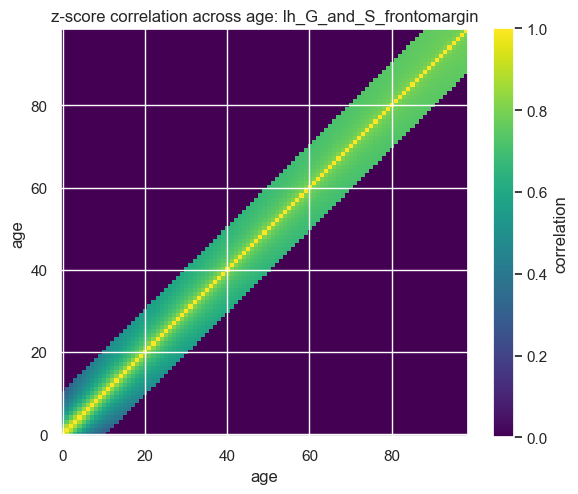

In [9]:
R = corr.matrix.sel(response_vars=REGION)

plt.figure(figsize=(6, 5))
plt.imshow(R.values, origin="lower", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="correlation")
plt.xlabel("age")
plt.ylabel("age")
plt.title(f"z-score correlation across age: {REGION}")
plt.tight_layout()
plt.show()

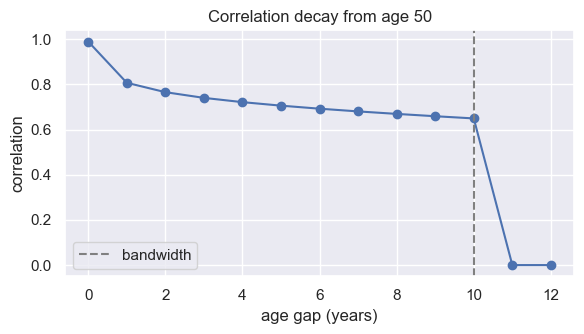

In [10]:
# The correlation at each age gap, read along one row.
age = 50
gaps = np.arange(0, (corr.bandwidth or 10) + 3)
values = [corr.get(REGION, age, age - g) for g in gaps]

plt.figure(figsize=(6, 3.5))
plt.plot(gaps, values, marker="o")
plt.axvline(corr.bandwidth, color="grey", ls="--", label="bandwidth")
plt.xlabel("age gap (years)")
plt.ylabel("correlation")
plt.title(f"Correlation decay from age {age}")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Load a normative model

The model supplies the mapping from z-scores back to real units (cortical
thickness in mm), which is what turns thrivelines in z-space into lines you can
draw on a centile plot.

We use a lifespan HBR model fitted on 79k subjects across 100 sites, for the
same region as the correlation matrix. It is downloaded from
[SURFdrive](https://surfdrive.surf.nl/s/Mb6mZyFmJeCaPcZ), which hosts one folder
per region; only `lh_G_and_S_frontomargin` is needed here.

In [11]:
import base64
from pathlib import Path
from urllib.request import Request, urlopen

MODEL_NAME = "HBR_Sb_ct_DES_lifespan_79K_100sites"
MODEL_PATH = Path("resources") / MODEL_NAME
SHARE_ID = "Mb6mZyFmJeCaPcZ"  # from the SURFdrive share link
WEBDAV = "https://surfdrive.surf.nl/public.php/webdav"

# The share id is the WebDAV username; the password is empty.
auth = base64.b64encode(f"{SHARE_ID}:".encode()).decode()

# Download once: the shared model metadata, plus this one region (~15 MB).
for relative in (
    "model/normative_model.json",
    f"model/{REGION}/regression_model.json",
    f"model/{REGION}/idata.nc",
):
    target = MODEL_PATH / relative
    if not target.exists():
        target.parent.mkdir(parents=True, exist_ok=True)
        request = Request(
            f"{WEBDAV}/{MODEL_NAME}/{relative}",
            headers={"Authorization": f"Basic {auth}"},
        )
        with urlopen(request) as response, open(target, "wb") as f:
            f.write(response.read())
        print("downloaded", relative)

model = NormativeModel.load(str(MODEL_PATH))
print("covariates:   ", model.covariates)
print("response vars:", list(model.response_vars))

covariates:    ['age']
response vars: ['lh_G_and_S_frontomargin']


C:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 9864 - 2026-08-13 16:41:00 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
C:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 9864 - 2026-08-13 16:41:00 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)


## 4. Compute thrivelines

`ZGainScore` takes the model and the matrix as inputs.

If the model has covariates besides age (sex, ICV, ...), those must be held at
some value to invert a z-score. Each is fixed to the midpoint of its range in
the model.

In [14]:
centiles = [0.05, 0.25, 0.5, 0.75, 0.95]

thrivelines = ZGainScore(model, corr).get_thrivelines(
    z_anchors=stats.norm.ppf(centiles),
)
thrivelines.head()

Sampling: []
Sampling: []


,segment,start_age,start_z,response_var,offset,X,Z,Y
0,0,0.0,-1.644854,lh_G_and_S_frontomargin,0,0.0,-1.644854,3.003392
1,0,0.0,-1.644854,lh_G_and_S_frontomargin,1,1.0,-2.265750,2.792222
2,1,0.0,-0.674490,lh_G_and_S_frontomargin,0,0.0,-0.674490,3.212478
3,1,0.0,-0.674490,lh_G_and_S_frontomargin,1,1.0,-1.368015,2.993245
4,2,0.0,0.000000,lh_G_and_S_frontomargin,0,0.0,0.000000,3.342607


Each row is one point on one thriveline segment. A segment is a starting
point (`start_age`, `start_z`) and where it is expected to land one year later,
so every segment has two rows: `offset` 0 and `offset` 1.

## 5. Plot them over the centiles

Each short line shows where someone at that age and z-score is expected to move
over one year. A subject who tracks along a thriveline is changing as expected;
one that crosses them steeply is not.

Process: 9864 - 2026-08-13 16:49:39 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 9864 - 2026-08-13 16:49:39 - Computing centiles for 1 response variables.
Process: 9864 - 2026-08-13 16:49:39 - Computing centiles for lh_G_and_S_frontomargin.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


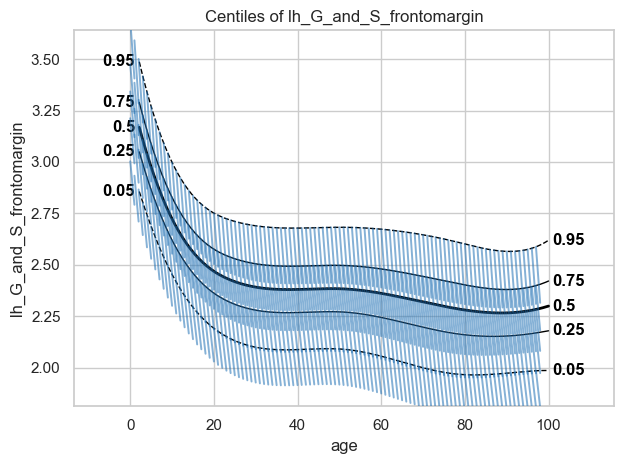

[<Figure size 640x480 with 1 Axes>]

In [15]:
plot_thrivelines(
    model,
    thrivelines=thrivelines,
    centiles=centiles,
    covariate="age",
    response_vars=[REGION],
)